In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [248]:
df = pd.read_csv('dataSP23.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


In [249]:
df.value_counts('neighbourhood_group')

neighbourhood_group
Manhattan        12129
Brooklyn         11255
Queens            3190
Bronx              604
Staten Island      201
Name: count, dtype: int64

In [250]:
df.value_counts('room_type')

room_type
Entire home/apt    14254
Private room       12486
Shared room          639
Name: count, dtype: int64

In [251]:
df.loc[df['room_type'] == 'Entire home/apt'].sort_values('price',ascending=False).head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
18103,18104,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83
7311,7312,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,9/15/2016,0.03,11,365
17270,17271,70' Luxury MotorYacht on the Hudson,7407743,Jack,Manhattan,Battery Park City,40.71162,-74.01693,Entire home/apt,7500,1,0,NaN,NaN,1,364
7876,7877,3000 sq ft daylight photo studio,3750764,Kevin,Manhattan,Chelsea,40.75060,-74.00388,Entire home/apt,6800,1,0,NaN,NaN,6,364
8270,8271,Park Avenue Mansion by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.78517,-73.95270,Entire home/apt,6419,1,0,NaN,NaN,12,45


In [252]:
df.loc[df['room_type'] == 'Private room'].sort_values('price',ascending=False).head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
26156,26157,Gem of east Flatbush,262534951,Sandra,Brooklyn,East Flatbush,40.65724,-73.92450,Private room,7500,1,8,7/7/2019,6.15,2,179
5577,5578,Beautiful private Brooklyn room with kitchenette,8748976,Jeffrey,Brooklyn,Bedford-Stuyvesant,40.68807,-73.95426,Private room,4200,114,0,NaN,NaN,1,347
15477,15478,CQ 1 Bedroom,30223355,Adrienne,Manhattan,Financial District,40.70706,-74.00991,Private room,3000,3,0,NaN,NaN,1,23
6066,6067,Beautiful 3 bedroom in Manhattan,256239,Tracey,Manhattan,Upper West Side,40.80142,-73.96931,Private room,3000,7,0,NaN,NaN,1,365
15674,15675,Recently Renovated & Furnished Apt- Room avail...,244008821,Sonia,Manhattan,West Village,40.73540,-74.00208,Private room,2850,100,0,NaN,NaN,1,270


In [253]:
df.loc[df['room_type'] == 'Shared room'].sort_values('price',ascending=False).head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
6966,6967,Mins away to Manhattan Suite Residence,24146326,Julien,Queens,Astoria,40.76626,-73.93054,Shared room,1800,3,5,4/9/2017,0.13,2,90
23168,23169,New York's Hidden Secret for luxury living,131826530,Kathy,Bronx,Riverdale,40.88515,-73.91411,Shared room,800,2,1,9/3/2017,0.04,3,269
9077,9078,"Park Avenue midtown apartment, walk to everything",1163709,Dc,Manhattan,Murray Hill,40.74836,-73.98070,Shared room,800,2,12,6/27/2019,1.40,1,220
6069,6070,Great for students!,51842673,Rayquila,Brooklyn,Bedford-Stuyvesant,40.68430,-73.93836,Shared room,725,1,0,NaN,NaN,1,0
20640,20641,Newly rennovated studio space in UWS,25115746,Stephanie,Manhattan,Upper West Side,40.78757,-73.97624,Shared room,500,1,0,NaN,NaN,1,89


In [254]:
print('Entire home/apt mean:', df.loc[df['room_type'] == 'Entire home/apt', 'price'].mean())
print('Private room mean:', df.loc[df['room_type'] == 'Private room', 'price'].mean())
print('Shared room mean:', df.loc[df['room_type'] == 'Shared room', 'price'].mean())

Entire home/apt mean: 210.9341237547355
Private room mean: 87.93216402370655
Shared room mean: 70.80907668231612


In [255]:
df['last_review_year'] = pd.to_datetime(df['last_review']).dt.year
year_list = df.value_counts('last_review_year').index.to_list()
for year in year_list:
    print(f'Mean price with last review in {year}', df.loc[df['last_review_year'] == year, 'price'].mean())

Mean price with last review in 2019.0 141.25796833960388
Mean price with last review in 2018.0 139.8725606150207
Mean price with last review in 2017.0 138.7384701912261
Mean price with last review in 2016.0 147.17896799477467
Mean price with last review in 2015.0 151.35985312117504
Mean price with last review in 2014.0 151.0
Mean price with last review in 2013.0 143.8181818181818
Mean price with last review in 2012.0 143.63636363636363
Mean price with last review in 2011.0 136.8


In [256]:
df.sort_values('calculated_host_listings_count', ascending=False)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year
16358,16359,Sonder | 116 John | Ideal 1BR + Gym,219517861,Sonder (NYC),Manhattan,Financial District,40.70722,-74.00499,Entire home/apt,164,29,0,NaN,NaN,327,328,NaN
25677,25678,Sonder | 180 Water | Pleasant 2BR + Rooftop,219517861,Sonder (NYC),Manhattan,Financial District,40.70575,-74.00621,Entire home/apt,302,29,0,NaN,NaN,327,190,NaN
4953,4954,Sonder | 116 John | Comfortable 1BR + Gym,219517861,Sonder (NYC),Manhattan,Financial District,40.70641,-74.00674,Entire home/apt,130,29,0,NaN,NaN,327,337,NaN
20838,20839,Sonder | Stock Exchange | Simple 1BR + Sofa Bed,219517861,Sonder (NYC),Manhattan,Financial District,40.70731,-74.01056,Entire home/apt,214,2,11,6/11/2019,3.20,327,312,2019.0
3084,3085,Sonder | Stock Exchange | Quaint Studio + Lounge,219517861,Sonder (NYC),Manhattan,Financial District,40.70651,-74.01252,Entire home/apt,203,2,9,6/20/2019,2.16,327,336,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,14,Nouveau Bohemian in East Village,35672187,Sharda,Manhattan,East Village,40.72196,-73.98345,Private room,108,2,36,6/21/2019,1.18,1,51,2019.0
9,10,Brooklyn Cozy Garden Apt,16385595,Ava,Brooklyn,Bedford-Stuyvesant,40.67994,-73.94318,Private room,105,14,26,6/5/2019,0.42,1,285,2019.0
7,8,Prospect Heights Garden Duplex,1157541,Damaris,Brooklyn,Prospect Heights,40.67625,-73.97038,Entire home/apt,166,30,1,3/5/2019,0.24,1,365,2019.0
5,6,Private Sunny Cool Bushwick Bedroom,94946,Taylor,Brooklyn,Bushwick,40.69746,-73.92065,Private room,101,1,28,6/8/2019,1.15,1,13,2019.0


In [257]:
df.sort_values('availability_365')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year
27362,27363,"Lovely Room for A Real, Cozy Brooklyn Experience",7756888,Joe,Brooklyn,Flatbush,40.63609,-73.96687,Private room,69,2,1,8/13/2017,0.04,1,0,2017.0
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0,2018.0
27375,27376,Beautiful apartment ~25min from Times Square,6358504,Yaroslav,Bronx,Mount Hope,40.84499,-73.91157,Entire home/apt,60,5,3,8/21/2018,0.13,1,0,2018.0
27374,27375,Dream home: Beautiful 2B2B Condo in Chelsea,106627653,Jacob,Manhattan,Chelsea,40.74735,-73.99974,Entire home/apt,585,3,7,8/4/2018,0.23,1,0,2018.0
27372,27373,Bedroom on Quiet Block on the Lower East Side,29111684,Samuel,Manhattan,Lower East Side,40.72167,-73.99075,Private room,85,30,2,3/20/2017,0.06,1,0,2017.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27334,27335,My Brooklyn Studio in Ditmas Park,3377231,Lina,Brooklyn,Flatbush,40.64895,-73.95758,Entire home/apt,140,4,15,8/3/2017,0.18,1,365,2017.0
15502,15503,"Nice & quiet,clean & neat, all including hostel",95958773,Maryna,Brooklyn,Brighton Beach,40.57811,-73.96004,Shared room,50,1,0,NaN,NaN,3,365,NaN
84,85,J- HOTEL STYLE SHARE ROOM FOR 2PPL FREE CABLE ...,8814258,Nikole,Queens,South Ozone Park,40.67324,-73.79570,Shared room,34,5,2,2/23/2019,0.23,7,365,2019.0
6445,6446,Double Twin Spacious Room In Small,17938076,Tyreq,Staten Island,Mariners Harbor,40.63630,-74.15911,Private room,200,1,0,NaN,NaN,1,365,NaN


In [258]:
bins = [0, 60, 120, 180, 240, 300, 366]
df['cut_available_365'] = pd.cut(df['availability_365'], bins=bins)
result_custom = df.groupby('cut_available_365', observed=True).agg(
    mean_price=('price', 'mean'),
    count_price=('price', 'count')
).reset_index()
print(result_custom)

  cut_available_365  mean_price  count_price
0           (0, 60]  136.504396         4663
1         (60, 120]  146.803505         2682
2        (120, 180]  170.229791         2202
3        (180, 240]  167.028234         1523
4        (240, 300]  176.626163         1934
5        (300, 366]  182.416505         4629


In [259]:
df['cut_available_365_q'] = pd.qcut(df['availability_365'], q=5, duplicates='drop')

result_custom = df.groupby('cut_available_365_q', observed=True).agg(
    mean_price=('price', 'mean'),
    count_price=('price', 'count')
).reset_index()
print(result_custom)

  cut_available_365_q  mean_price  count_price
0       (-0.001, 8.0]  133.449133        11019
1         (8.0, 94.0]  142.208295         5425
2       (94.0, 274.0]  169.298978         5482
3      (274.0, 365.0]  179.675408         5453


In [260]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,cut_available_365,cut_available_365_q
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0,2018.0,NaN,"(-0.001, 8.0]"
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250,2017.0,"(240.0, 300.0]","(94.0, 274.0]"
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74,2019.0,"(60.0, 120.0]","(8.0, 94.0]"
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0,2019.0,NaN,"(-0.001, 8.0]"
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20,2019.0,"(0.0, 60.0]","(8.0, 94.0]"


In [261]:
df = df.drop(columns=['name', 'id', 'host_id', 'host_name', 'neighbourhood', 'last_review', 'last_review_year', 'cut_available_365', 'cut_available_365_q'])
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0.10,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,4,0.17,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,126,3.74,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,95,5.63,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,88,4.41,1,20


In [262]:
df['nights'] = pd.qcut(df['minimum_nights'], q=7, duplicates='drop')
df.groupby('nights').agg(
    mean=('price', 'mean'),
    count=('price', 'count')
).reset_index()

,nights,mean,count
0,"(0.999, 2.0]",143.450140,13618
1,"(2.0, 3.0]",161.919587,4452
2,"(3.0, 4.0]",161.257821,1854
3,"(4.0, 10.0]",145.706649,3685
4,"(10.0, 999.0]",169.642440,3770


In [263]:
df = df.drop(columns=['nights'])

In [264]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,27379.0,40.728836,0.054629,40.50641,40.689955,40.72303,40.763045,40.91306
longitude,27379.0,-73.952071,0.046278,-74.24285,-73.983080,-73.95570,-73.935830,-73.71795
price,27379.0,151.569561,219.807784,0.00000,69.000000,105.00000,175.000000,10000.00000
minimum_nights,27379.0,7.056722,20.194945,1.00000,1.000000,3.00000,5.000000,999.00000
number_of_reviews,27379.0,23.228131,44.281418,0.00000,1.000000,5.00000,23.000000,607.00000
reviews_per_month,21746.0,1.383797,1.714116,0.01000,0.190000,0.72000,2.030000,58.50000
calculated_host_listings_count,27379.0,7.228788,33.173634,1.00000,1.000000,1.00000,2.000000,327.00000
availability_365,27379.0,113.430293,132.039807,0.00000,0.000000,45.00000,230.000000,365.00000


In [265]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27379 entries, 0 to 27378
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             27379 non-null  str    
 1   latitude                        27379 non-null  float64
 2   longitude                       27379 non-null  float64
 3   room_type                       27379 non-null  str    
 4   price                           27379 non-null  int64  
 5   minimum_nights                  27379 non-null  int64  
 6   number_of_reviews               27379 non-null  int64  
 7   reviews_per_month               21746 non-null  float64
 8   calculated_host_listings_count  27379 non-null  int64  
 9   availability_365                27379 non-null  int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 2.1 MB


In [266]:
quality_report = {
    'total_records': len(df),
    'missing_values': df.isna().sum().to_dict(),
    'duplicate_rows': df.duplicated().sum()
}

pd.DataFrame(quality_report)

,total_records,missing_values,duplicate_rows
neighbourhood_group,27379,0,0
latitude,27379,0,0
longitude,27379,0,0
room_type,27379,0,0
price,27379,0,0
minimum_nights,27379,0,0
number_of_reviews,27379,0,0
reviews_per_month,27379,5633,0
calculated_host_listings_count,27379,0,0
availability_365,27379,0,0


<Axes: >

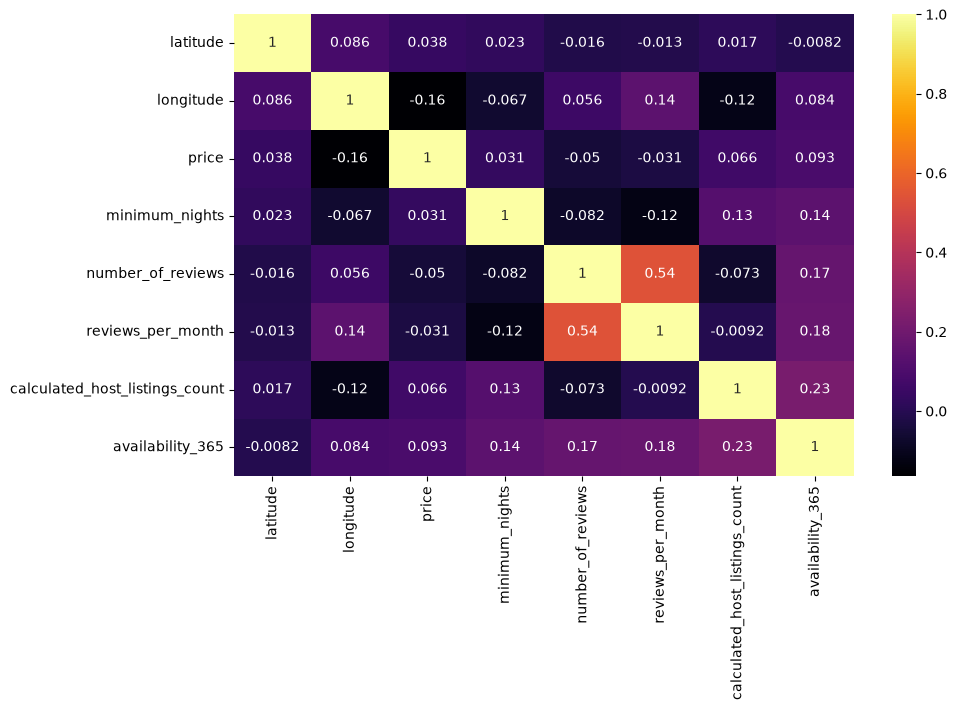

In [267]:
df_copy = df.copy().select_dtypes(include=['number'])

correl_matrix = df_copy.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correl_matrix, cmap='inferno', annot=True, fmt='.2g')

In [268]:
df['price'] = np.log1p(df['price'])

In [269]:
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,4.077537,2,1,0.10,1,0
1,Brooklyn,40.68769,-73.97490,Private room,4.605170,5,4,0.17,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,5.198497,2,126,3.74,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,3.931826,1,95,5.63,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,5.351858,4,88,4.41,1,20


In [270]:
# for column in df.select_dtypes(include=['number']):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - IQR * 1.5
#     upper_bound = Q3 + IQR * 1.5
#     outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
#     print(f'Number of outliers in {column} (size of df - {len(df)}):', outlier_mask.sum())
#     df = df[~outlier_mask]
#     print('df size after deleting outliers:', len(df))

In [271]:
df = df.drop(columns=['minimum_nights', 'number_of_reviews', 'reviews_per_month'])

In [272]:
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,4.077537,1,0
1,Brooklyn,40.68769,-73.97490,Private room,4.605170,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,5.198497,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,3.931826,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,5.351858,1,20


In [273]:
upper_limit = df['calculated_host_listings_count'].quantile(0.99)
df['calculated_host_listings_count'] = df['calculated_host_listings_count'].clip(upper=upper_limit)

<Axes: xlabel='longitude', ylabel='latitude'>

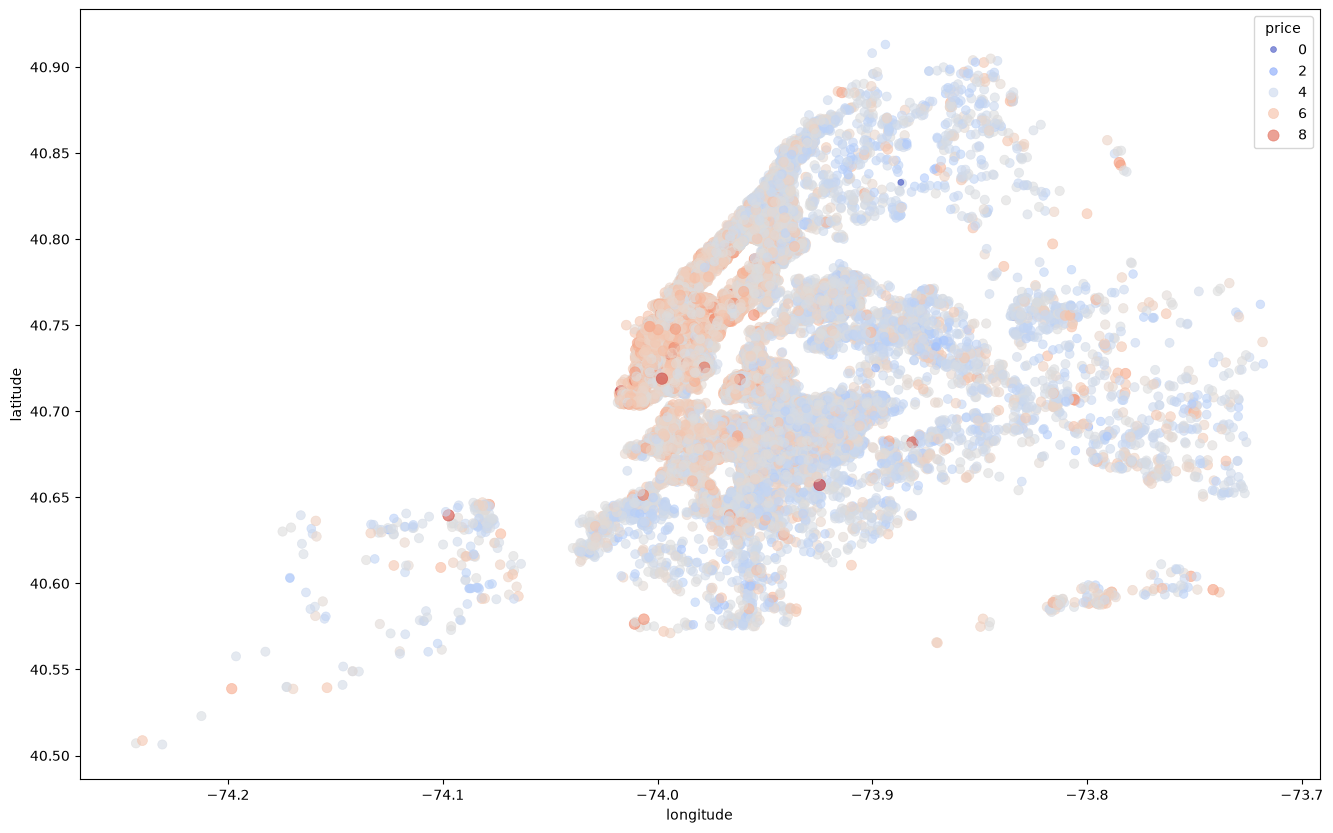

In [274]:
plt.figure(figsize=(16, 10))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price',
    size='price',
    palette='coolwarm',
    edgecolor=None,
    alpha=0.6
)

In [275]:
X = df.copy().drop(columns=['price'])
y = df.copy()['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    )

preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['latitude', 'longitude', 'calculated_host_listings_count', 'availability_365']),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['neighbourhood_group']),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['room_type'])
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [276]:
X_train = pd.DataFrame(X_train)
X_train.head()

,0,1,2,3,4,5,6,7,8
0,-0.145532,-0.612851,-0.203165,0.205345,0.0,1.0,0.0,0.0,0.0
1,1.149872,-0.326187,-0.129587,-0.834943,0.0,1.0,0.0,0.0,0.0
2,0.228089,-0.922483,8.295010,1.594927,0.0,1.0,0.0,0.0,0.0
3,0.559221,-0.776659,-0.203165,-0.789383,0.0,1.0,0.0,0.0,1.0
4,-0.272271,-0.121210,-0.203165,-0.857723,1.0,0.0,0.0,0.0,0.0


In [277]:
y_train.head()

12261    5.690359
23613    5.170484
20729    5.840642
17968    5.278115
21594    5.017280
Name: price, dtype: float64

In [278]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [279]:
y_test = np.expm1(y_test)
y_pred = np.expm1(y_pred)

metrics = {
    'MAE': mean_absolute_error(y_test, y_pred),
    'MSE': mean_squared_error(y_test, y_pred),
    'RMSE': root_mean_squared_error(y_test, y_pred),
    'R^2': r2_score(y_test, y_pred)
}

pd.DataFrame(metrics, index=['Value']).T


,Value
MAE,59.185593
MSE,27014.250013
RMSE,164.360123
R^2,0.143779
